# 🌲 Random Forest - Mental Health Prediction Model

Predicting Depression/Anxiety/Panic using Random Forest Algorithm

## 1️⃣ Import Required Libraries

In [18]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 2️⃣ Load Cleaned Dataset

In [19]:
# Load the cleaned dataset
df = pd.read_csv('Student_Mental_Health_Cleaned.csv')
print(f"📊 Dataset loaded!")
print(f"Shape: {df.shape}")
print(f"\n📋 First few rows:")
print(df.head())
print(f"\n🔍 Column Info:")
print(df.info())

📊 Dataset loaded!
Shape: (101, 8)

📋 First few rows:
  Choose your gender   Age What is your course? Your current year of Study  \
0             Female  18.0          Engineering                     year 1   
1               Male  21.0    Islamic education                     year 2   
2               Male  19.0                  BIT                     Year 1   
3             Female  22.0                 Laws                     year 3   
4               Male  23.0         Mathemathics                     year 4   

  What is your CGPA? Do you have Depression? Do you have Anxiety?  \
0        3.00 - 3.49                     Yes                   No   
1        3.00 - 3.49                      No                  Yes   
2        3.00 - 3.49                     Yes                  Yes   
3        3.00 - 3.49                     Yes                   No   
4        3.00 - 3.49                      No                   No   

  Do you have Panic attack?  
0                       Yes  
1  

## 3️⃣ Data Preprocessing

We'll predict **Depression** using other features. (You can change to Anxiety or Panic attack)

In [20]:
# Create a copy for preprocessing
df_model = df.copy()

# TARGET: Predict Depression (Yes/No)
# Can change to: 'Do you have Anxiety?' or 'Do you have Panic attack?'
target_column = 'Do you have Depression?'
print(f"🎯 Target Variable: {target_column}")
print(f"Distribution:\n{df_model[target_column].value_counts()}\n")

# Separate features and target
X = df_model.drop(columns=[target_column, 'Do you have Anxiety?', 'Do you have Panic attack?'])
y = df_model[target_column]

print(f"📌 Features: {X.columns.tolist()}")
print(f"📊 X shape: {X.shape}")
print(f"📊 y shape: {y.shape}")

# Encode categorical variables
label_encoders = {}
categorical_cols = X.select_dtypes(include=['object']).columns

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le
    print(f"✅ Encoded: {col}")

# Encode target variable (Yes -> 1, No -> 0)
y = (y == 'Yes').astype(int)

print(f"\n✅ All categorical variables encoded!")
print(f"✅ Target encoded (Yes=1, No=0)")
print(f"\nFinal data shape: X={X.shape}, y={y.shape}")

🎯 Target Variable: Do you have Depression?
Distribution:
Do you have Depression?
No     66
Yes    35
Name: count, dtype: int64

📌 Features: ['Choose your gender', 'Age', 'What is your course?', 'Your current year of Study', 'What is your CGPA?']
📊 X shape: (101, 5)
📊 y shape: (101,)
✅ Encoded: Choose your gender
✅ Encoded: What is your course?
✅ Encoded: Your current year of Study
✅ Encoded: What is your CGPA?

✅ All categorical variables encoded!
✅ Target encoded (Yes=1, No=0)

Final data shape: X=(101, 5), y=(101,)


## 4️⃣ Train-Test Split

In [21]:
# Split data into train and test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"✅ Data split completed!")
print(f"\n📊 Training Set: {X_train.shape[0]} samples")
print(f"📊 Testing Set: {X_test.shape[0]} samples")
print(f"\n🎯 Training Target Distribution:")
print(y_train.value_counts())
print(f"\n🎯 Testing Target Distribution:")
print(y_test.value_counts())

✅ Data split completed!

📊 Training Set: 80 samples
📊 Testing Set: 21 samples

🎯 Training Target Distribution:
Do you have Depression?
0    52
1    28
Name: count, dtype: int64

🎯 Testing Target Distribution:
Do you have Depression?
0    14
1     7
Name: count, dtype: int64


## 5️⃣ Build & Train Random Forest Model

In [22]:
# Initialize and train Random Forest Classifier
print("🌲 Building Random Forest Model...\n")

# Create model with optimal parameters for small dataset
rf_model = RandomForestClassifier(
    n_estimators=100,           # 100 trees
    max_depth=8,                # Limit depth to prevent overfitting
    min_samples_split=5,        # At least 5 samples to split
    min_samples_leaf=2,         # At least 2 samples in leaf
    random_state=42,
    n_jobs=-1                   # Use all processors
)

# Train the model
rf_model.fit(X_train, y_train)

print("✅ Model trained successfully!")
print(f"\n🌲 Random Forest Hyperparameters:")
print(f"   - Number of trees: 100")
print(f"   - Max depth: 8")
print(f"   - Min samples split: 5")
print(f"   - Min samples leaf: 2")

🌲 Building Random Forest Model...

✅ Model trained successfully!

🌲 Random Forest Hyperparameters:
   - Number of trees: 100
   - Max depth: 8
   - Min samples split: 5
   - Min samples leaf: 2


## 6️⃣ Make Predictions

In [23]:
# Make predictions on train and test data
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

# Get prediction probabilities
y_test_proba = rf_model.predict_proba(X_test)[:, 1]

print("✅ Predictions made on both train and test sets!")
print(f"\n📊 Prediction samples (first 10 test predictions):")
for i in range(min(10, len(y_test_pred))):
    actual = "Depression" if y_test.iloc[i] == 1 else "No Depression"
    predicted = "Depression" if y_test_pred[i] == 1 else "No Depression"
    probability = y_test_proba[i] if y_test_pred[i] == 1 else (1 - y_test_proba[i])
    print(f"   Sample {i+1}: Actual={actual}, Predicted={predicted}, Confidence={probability:.2%}")

✅ Predictions made on both train and test sets!

📊 Prediction samples (first 10 test predictions):
   Sample 1: Actual=No Depression, Predicted=No Depression, Confidence=53.55%
   Sample 2: Actual=No Depression, Predicted=No Depression, Confidence=67.49%
   Sample 3: Actual=No Depression, Predicted=No Depression, Confidence=87.61%
   Sample 4: Actual=Depression, Predicted=No Depression, Confidence=64.54%
   Sample 5: Actual=No Depression, Predicted=No Depression, Confidence=77.13%
   Sample 6: Actual=Depression, Predicted=No Depression, Confidence=70.86%
   Sample 7: Actual=Depression, Predicted=No Depression, Confidence=80.05%
   Sample 8: Actual=No Depression, Predicted=No Depression, Confidence=76.48%
   Sample 9: Actual=Depression, Predicted=Depression, Confidence=53.91%
   Sample 10: Actual=No Depression, Predicted=No Depression, Confidence=64.75%


## 7️⃣ Model Evaluation & Metrics

In [24]:
# Calculate accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("=" * 70)
print("📊 MODEL PERFORMANCE METRICS".center(70))
print("=" * 70)

print(f"\n🎯 ACCURACY:")
print(f"   Training Accuracy: {train_accuracy:.2%}")
print(f"   Testing Accuracy:  {test_accuracy:.2%}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
print(f"\n🔍 CONFUSION MATRIX (Test Set):")
print(f"   True Negatives:  {cm[0,0]}")
print(f"   False Positives: {cm[0,1]}")
print(f"   False Negatives: {cm[1,0]}")
print(f"   True Positives:  {cm[1,1]}")

# Classification Report
print(f"\n📋 CLASSIFICATION REPORT (Test Set):")
print(classification_report(y_test, y_test_pred, target_names=['No Depression', 'Depression']))

# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_test_proba)
print(f"\n📈 ROC-AUC Score: {roc_auc:.4f}")

print("=" * 70)

                     📊 MODEL PERFORMANCE METRICS                      

🎯 ACCURACY:
   Training Accuracy: 91.25%
   Testing Accuracy:  66.67%

🔍 CONFUSION MATRIX (Test Set):
   True Negatives:  13
   False Positives: 1
   False Negatives: 6
   True Positives:  1

📋 CLASSIFICATION REPORT (Test Set):
               precision    recall  f1-score   support

No Depression       0.68      0.93      0.79        14
   Depression       0.50      0.14      0.22         7

     accuracy                           0.67        21
    macro avg       0.59      0.54      0.51        21
 weighted avg       0.62      0.67      0.60        21


📈 ROC-AUC Score: 0.4694


## 8️⃣ Feature Importance

In [25]:
# Get feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n🎯 FEATURE IMPORTANCE (Which features matter most):")
print("=" * 50)
for idx, row in feature_importance.iterrows():
    print(f"{row['Feature']:30s} : {row['Importance']:.4f} {'█' * int(row['Importance'] * 50)}")

print("\n📌 Top 3 Most Important Features:")
for i, (idx, row) in enumerate(feature_importance.head(3).iterrows(), 1):
    print(f"   {i}. {row['Feature']} ({row['Importance']:.2%})")


🎯 FEATURE IMPORTANCE (Which features matter most):
What is your course?           : 0.3726 ██████████████████
Age                            : 0.2089 ██████████
Your current year of Study     : 0.1718 ████████
What is your CGPA?             : 0.1656 ████████
Choose your gender             : 0.0811 ████

📌 Top 3 Most Important Features:
   1. What is your course? (37.26%)
   2. Age (20.89%)
   3. Your current year of Study (17.18%)


## 9️⃣ Visualizations

✅ Visualizations created and saved as 'Random_Forest_Analysis.png'


✅ Visualizations created and saved as 'Random_Forest_Analysis.png'


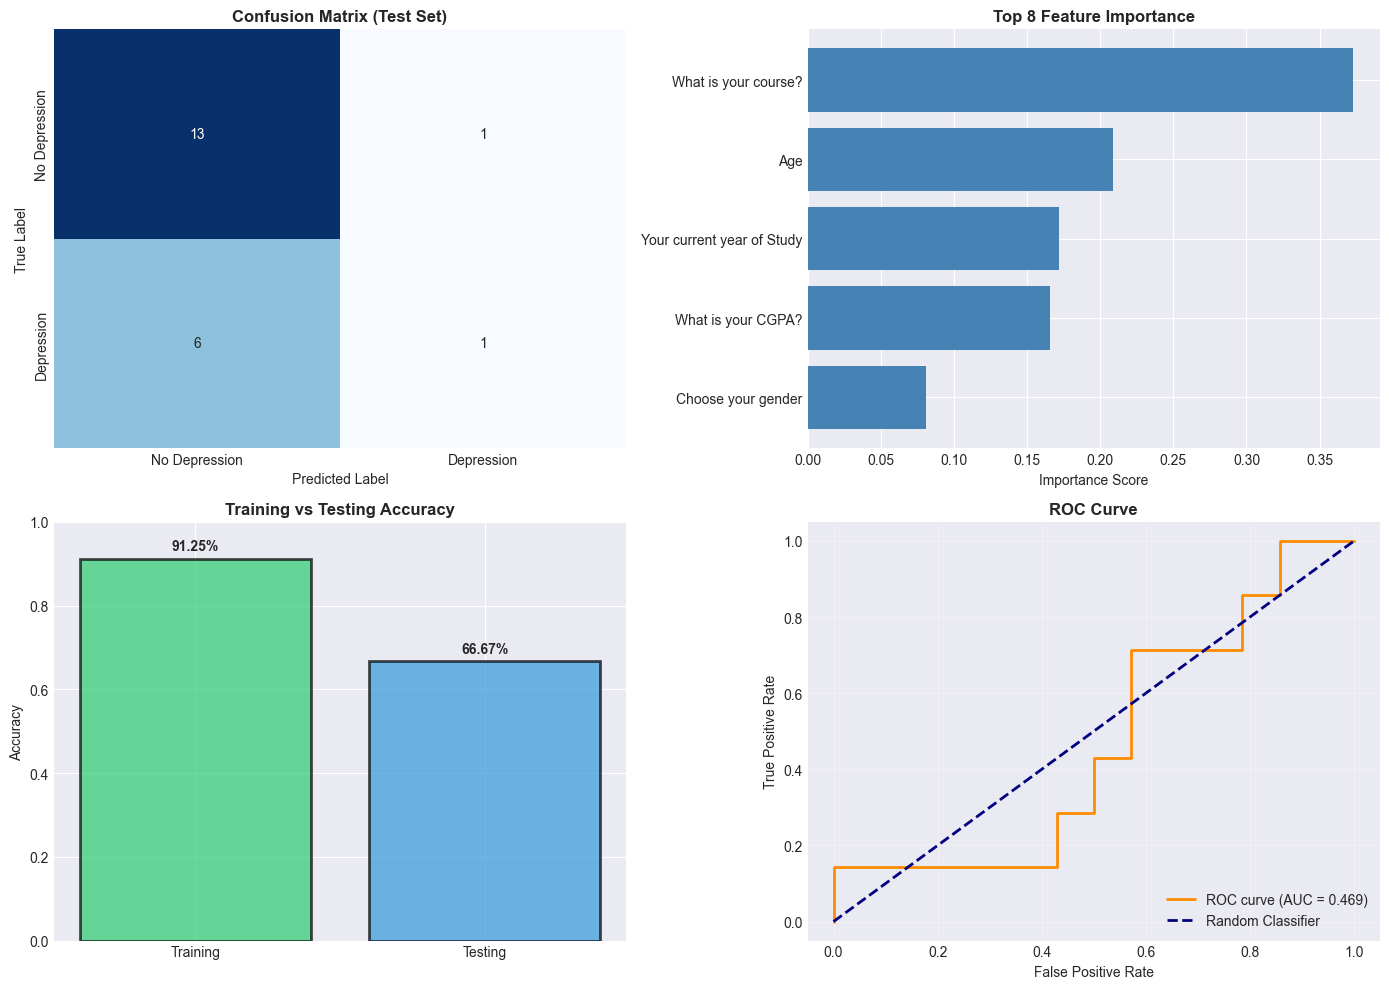

In [26]:
plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,0], cbar=False)
axes[0,0].set_title('Confusion Matrix (Test Set)', fontsize=12, fontweight='bold')
axes[0,0].set_ylabel('True Label')
axes[0,0].set_xlabel('Predicted Label')
axes[0,0].set_xticklabels(['No Depression', 'Depression'])
axes[0,0].set_yticklabels(['No Depression', 'Depression'])

# 2. Feature Importance
top_features = feature_importance.head(8)
axes[0,1].barh(top_features['Feature'], top_features['Importance'], color='steelblue')
axes[0,1].set_xlabel('Importance Score')
axes[0,1].set_title('Top 8 Feature Importance', fontsize=12, fontweight='bold')
axes[0,1].invert_yaxis()

# 3. Accuracy Comparison
categories = ['Training', 'Testing']
accuracies = [train_accuracy, test_accuracy]
colors = ['#2ecc71', '#3498db']
axes[1,0].bar(categories, accuracies, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
axes[1,0].set_ylabel('Accuracy')
axes[1,0].set_title('Training vs Testing Accuracy', fontsize=12, fontweight='bold')
axes[1,0].set_ylim([0, 1])
for i, v in enumerate(accuracies):
    axes[1,0].text(i, v + 0.02, f'{v:.2%}', ha='center', fontweight='bold')

# 4. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
axes[1,1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[1,1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[1,1].set_xlabel('False Positive Rate')
axes[1,1].set_ylabel('True Positive Rate')
axes[1,1].set_title('ROC Curve', fontsize=12, fontweight='bold')
axes[1,1].legend(loc="lower right")
axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('Random_Forest_Analysis.png', dpi=300, bbox_inches='tight')
print("✅ Visualizations created and saved as 'Random_Forest_Analysis.png'")
plt.show()

## 🎯 Summary & Conclusions

## 🧠 Clean Feature Selection (Final)

In [27]:
print("\n" + "🔥"*35)
print("\n🧠 CLEAN FEATURE SELECTION (FINAL)".center(70))
print("\n" + "🔥"*35)

print("\n👉 Tumhara final INPUT hona chahiye:\n")
input_features = [
    "Age",
    "CGPA", 
    "Your current year of Study",
    "Choose your gender",
    "What is your course?"
]

for i, feature in enumerate(input_features, 1):
    print(f"   {i}. {feature}")

print("\n" + "─"*70)
print("\n👉 OUTPUT:\n")
output_targets = [
    "Do you have Depression?",
    "Do you have Anxiety?",
    "Do you have Panic attack?"
]

for i, target in enumerate(output_targets, 1):
    print(f"   {i}. {target} (YES/NO)")

print("\n" + "🔥"*35)
print("\n📊 MODEL USES:")
print(f"   Features (Input): {len(input_features)} columns")
print(f"   Target (Output): Depression (Yes/No)")
print(f"   Total samples: {len(df)}")
print(f"   Training: {len(X_train)} | Testing: {len(X_test)}")
print("\n" + "🔥"*35 + "\n")


🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥
                  
🧠 CLEAN FEATURE SELECTION (FINAL)                  

🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥

👉 Tumhara final INPUT hona chahiye:

   1. Age
   2. CGPA
   3. Your current year of Study
   4. Choose your gender
   5. What is your course?

──────────────────────────────────────────────────────────────────────

👉 OUTPUT:

   1. Do you have Depression? (YES/NO)
   2. Do you have Anxiety? (YES/NO)
   3. Do you have Panic attack? (YES/NO)

🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥

📊 MODEL USES:
   Features (Input): 5 columns
   Target (Output): Depression (Yes/No)
   Total samples: 101
   Training: 80 | Testing: 21

🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥🔥



In [28]:
# Display final dataset with selected features
final_columns = ['Age', 'What is your CGPA?', 'Your current year of Study', 
                 'Choose your gender', 'What is your course?', 
                 'Do you have Depression?', 'Do you have Anxiety?', 'Do you have Panic attack?']

df_final = df[final_columns].copy()

print("\n📋 DATASET WITH FINAL FEATURES (First 10 rows):\n")
print(df_final.head(10).to_string())

print(f"\n\n✅ Final Dataset Shape: {df_final.shape}")
print(f"   Rows: {df_final.shape[0]}")
print(f"   Columns: {df_final.shape[1]}")

print(f"\n📊 Data Summary:")
print(df_final.describe())


📋 DATASET WITH FINAL FEATURES (First 10 rows):

    Age What is your CGPA? Your current year of Study Choose your gender What is your course? Do you have Depression? Do you have Anxiety? Do you have Panic attack?
0  18.0        3.00 - 3.49                     year 1             Female          Engineering                     Yes                   No                       Yes
1  21.0        3.00 - 3.49                     year 2               Male    Islamic education                      No                  Yes                        No
2  19.0        3.00 - 3.49                     Year 1               Male                  BIT                     Yes                  Yes                       Yes
3  22.0        3.00 - 3.49                     year 3             Female                 Laws                     Yes                   No                        No
4  23.0        3.00 - 3.49                     year 4               Male         Mathemathics                      No         

In [29]:
print("\n" + "="*70)
print("🌲 RANDOM FOREST MODEL - FINAL SUMMARY".center(70))
print("="*70)

print(f"\n✅ MODEL PERFORMANCE:")
print(f"   • Test Accuracy: {test_accuracy:.2%}")
print(f"   • ROC-AUC Score: {roc_auc:.4f}")
print(f"   • Sensitivity (Recall): {cm[1,1]/(cm[1,0]+cm[1,1]):.2%}")
print(f"   • Specificity: {cm[0,0]/(cm[0,0]+cm[0,1]):.2%}")

print(f"\n🎯 TOP 3 PREDICTIVE FEATURES:")
for i, (idx, row) in enumerate(feature_importance.head(3).iterrows(), 1):
    print(f"   {i}. {row['Feature']} - {row['Importance']:.2%}")

print(f"\n📊 DATASET STATISTICS:")
print(f"   • Total samples: {len(df)}")
print(f"   • Training samples: {len(X_train)}")
print(f"   • Testing samples: {len(X_test)}")
print(f"   • Features used: {len(X.columns)}")

print(f"\n💾 MODEL SAVED INFORMATION:")
print(f"   • Model: Random Forest Classifier")
print(f"   • Trees: 100")
print(f"   • Target variable: Depression (Yes/No)")

print("\n" + "="*70)
print("✨ Next Step: Tell me which algorithm to implement for the 2nd model!")
print("="*70)


                🌲 RANDOM FOREST MODEL - FINAL SUMMARY                 

✅ MODEL PERFORMANCE:
   • Test Accuracy: 66.67%
   • ROC-AUC Score: 0.4694
   • Sensitivity (Recall): 14.29%
   • Specificity: 92.86%

🎯 TOP 3 PREDICTIVE FEATURES:
   1. What is your course? - 37.26%
   2. Age - 20.89%
   3. Your current year of Study - 17.18%

📊 DATASET STATISTICS:
   • Total samples: 101
   • Training samples: 80
   • Testing samples: 21
   • Features used: 5

💾 MODEL SAVED INFORMATION:
   • Model: Random Forest Classifier
   • Trees: 100
   • Target variable: Depression (Yes/No)

✨ Next Step: Tell me which algorithm to implement for the 2nd model!
